Epoch 1/10 | Loss: 0.0310
Epoch 2/10 | Loss: 0.0080
Epoch 3/10 | Loss: 0.0065
Epoch 4/10 | Loss: 0.0057
Epoch 5/10 | Loss: 0.0053
Epoch 6/10 | Loss: 0.0049
Epoch 7/10 | Loss: 0.0047
Epoch 8/10 | Loss: 0.0045
Epoch 9/10 | Loss: 0.0044
Epoch 10/10 | Loss: 0.0043


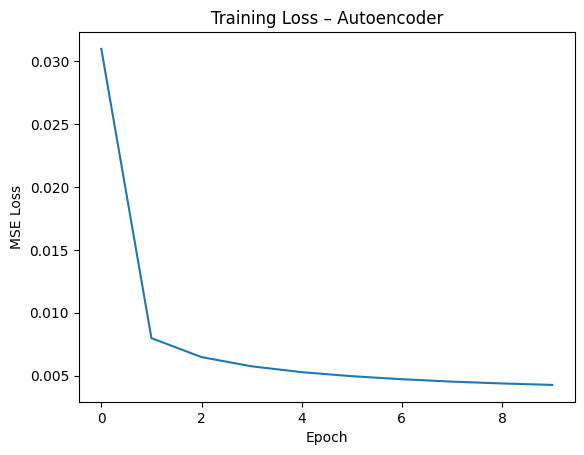

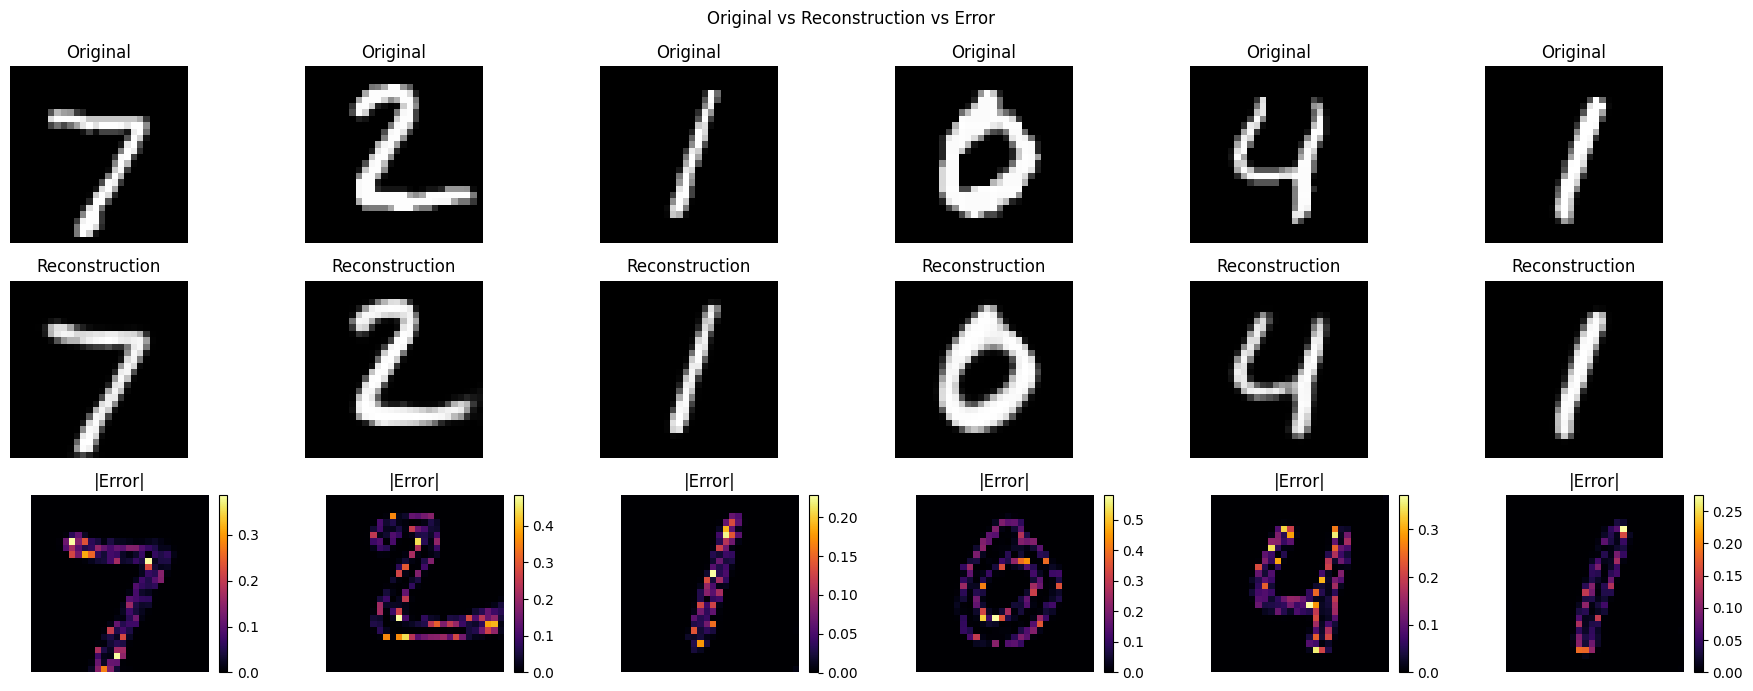

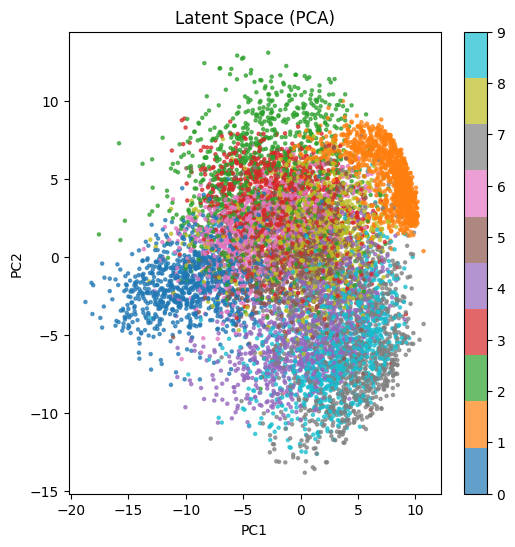

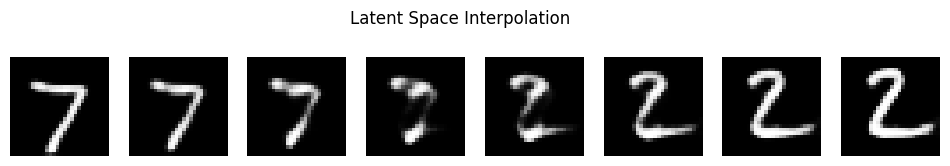

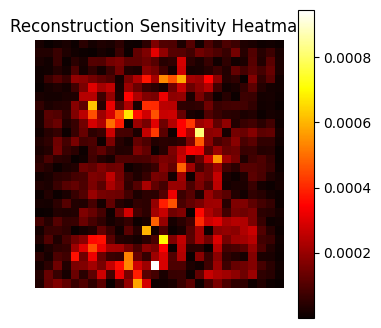

In [2]:
# Full Autoencoder training + extended visual diagnostics on MNIST

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# --------------------
# Configuration
# --------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 128
epochs = 10
latent_dim = 32
lr = 1e-3

# --------------------
# Data
# --------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --------------------
# Model
# --------------------
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), # 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim)
        )

        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),  # 28x28
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        return self.decoder(x)

model = Autoencoder(latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# --------------------
# Training
# --------------------
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")

# --------------------
# Loss plot
# --------------------
plt.figure()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss – Autoencoder")
plt.show()

# ============================================================
# VISUAL DIAGNOSTICS
# ============================================================

# --------------------
# 1. Reconstruction + Error map
# --------------------
model.eval()
with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    recon = model(images)

images = images.cpu()
recon = recon.cpu()
error = torch.abs(images - recon)

n = 6
plt.figure(figsize=(18, 7))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(images[i][0], cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(recon[i][0], cmap="gray")
    plt.title("Reconstruction")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(error[i][0], cmap="inferno")
    plt.title("|Error|")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

plt.suptitle("Original vs Reconstruction vs Error")
plt.tight_layout()
plt.show()

# --------------------
# 2. Latent space visualization (PCA)
# --------------------
latents = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        z = model.encoder(x.to(device))
        latents.append(z.cpu())
        labels.append(y)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

z_2d = PCA(n_components=2).fit_transform(latents)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=5,
    alpha=0.7
)
plt.colorbar(scatter)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent Space (PCA)")
plt.show()

# --------------------
# 3. Latent space interpolation
# --------------------
model.eval()
x1, _ = test_dataset[0]
x2, _ = test_dataset[1]

with torch.no_grad():
    z1 = model.encoder(x1.unsqueeze(0).to(device))
    z2 = model.encoder(x2.unsqueeze(0).to(device))

    alphas = torch.linspace(0, 1, 8)
    recon_interp = []

    for a in alphas:
        z = (1 - a) * z1 + a * z2
        x_hat = model.decoder_fc(z)
        x_hat = x_hat.view(-1, 64, 7, 7)
        x_hat = model.decoder(x_hat)
        recon_interp.append(x_hat.cpu())

plt.figure(figsize=(12, 2))
for i, img in enumerate(recon_interp):
    plt.subplot(1, 8, i + 1)
    plt.imshow(img[0][0], cmap="gray")
    plt.axis("off")

plt.suptitle("Latent Space Interpolation")
plt.show()

# --------------------
# Reconstruction sensitivity heatmap (saliency)
# --------------------
model.eval()

x, _ = test_dataset[0]
x = x.unsqueeze(0).to(device)
x.requires_grad = True

x_hat = model(x)
loss = ((x_hat - x) ** 2).mean()
loss.backward()

saliency = x.grad.abs().cpu()[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(saliency, cmap="hot")
plt.colorbar()
plt.title("Reconstruction Sensitivity Heatmap")
plt.axis("off")
plt.show()


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

LATENT_DIM = 100
BATCH_SIZE = 128
EPOCHS = 10
LR = 2e-4

# ---- Dane ----
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# ---- Modele ----
class Generator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 28 * 28),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, LATENT_DIM, device=device)

# ---- Trening ----
for epoch in range(1, EPOCHS + 1):
    for real, _ in dl:
        real = real.to(device)
        bs = real.size(0)

        # --- uczymy Dyskryminator ---
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake = G(z).detach()

        pred_real = D(real)
        pred_fake = D(fake)

        y_real = torch.ones(bs, 1, device=device)
        y_fake = torch.zeros(bs, 1, device=device)

        loss_D = criterion(pred_real, y_real) + criterion(pred_fake, y_fake)

        opt_D.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D.step()

        # --- uczymy Generator ---
        z = torch.randn(bs, LATENT_DIM, device=device)
        fake = G(z)
        pred = D(fake)

        loss_G = criterion(pred, y_real)  # generator chce "oszukać" Dyskryminator

        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G.step()

    with torch.no_grad():
        samples = G(fixed_noise).cpu()
    grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
    utils.save_image(grid, f"gan_samples_epoch_{epoch:02d}.png")
    print(f"Epoch {epoch}/{EPOCHS} | loss_D={loss_D.item():.4f} | loss_G={loss_G.item():.4f}")


Epoch 1/10 | loss_D=0.7572 | loss_G=1.8749
Epoch 2/10 | loss_D=0.6552 | loss_G=2.5593
Epoch 3/10 | loss_D=0.7032 | loss_G=1.5654
Epoch 4/10 | loss_D=0.8734 | loss_G=1.8458
Epoch 5/10 | loss_D=0.7951 | loss_G=2.0115
Epoch 6/10 | loss_D=0.8370 | loss_G=3.0322
Epoch 7/10 | loss_D=0.8790 | loss_G=1.5459
Epoch 8/10 | loss_D=0.6657 | loss_G=2.0991
Epoch 9/10 | loss_D=0.6841 | loss_G=1.8366
Epoch 10/10 | loss_D=0.8506 | loss_G=1.4169


In [4]:
# pip install torch torchvision matplotlib scikit-learn

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# ----------------------------
# Config
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

LATENT_DIM = 128
BATCH_SIZE = 128
EPOCHS = 30
LR = 2e-4
THRESH = 0.5

OUT_DIR = "./gan_cifar10_out"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# Data: CIFAR-10 (3x32x32)
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))  # -> [-1,1]
])

train_ds = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_dl = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

# ----------------------------
# Models (DCGAN-style)
# ----------------------------
class Generator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # RGB in [-1,1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

# ----------------------------
# Train GAN
# ----------------------------
for epoch in range(1, EPOCHS + 1):
    G.train()
    D.train()

    for real_imgs, _ in train_dl:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        # ---- Train D ----
        z = torch.randn(bs, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(z).detach()

        y_real = torch.ones(bs, 1, device=device)
        y_fake = torch.zeros(bs, 1, device=device)

        loss_D = (
            criterion(D(real_imgs), y_real) +
            criterion(D(fake_imgs), y_fake)
        )

        opt_D.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D.step()

        # ---- Train G ----
        z = torch.randn(bs, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G(z)
        loss_G = criterion(D(fake_imgs), y_real)

        opt_G.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G.step()

    # Save samples
    G.eval()
    with torch.no_grad():
        samples = G(fixed_noise).cpu()
    grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
    utils.save_image(grid, f"{OUT_DIR}/samples_epoch_{epoch:03d}.png")

    print(f"Epoch {epoch}/{EPOCHS} | loss_D={loss_D.item():.4f} | loss_G={loss_G.item():.4f}")

# ----------------------------
# Evaluation: D vs TRUE labels
# ----------------------------
G.eval()
D.eval()

N_REAL = 2000
N_FAKE = 2000

# Real images
real_imgs = []
it = iter(train_dl)
while len(real_imgs) * BATCH_SIZE < N_REAL:
    batch, _ = next(it)
    real_imgs.append(batch)
real_imgs = torch.cat(real_imgs, dim=0)[:N_REAL].to(device)

# Fake images
z = torch.randn(N_FAKE, LATENT_DIM, 1, 1, device=device)
with torch.no_grad():
    fake_imgs = G(z)

# Stack + labels
x_eval = torch.cat([real_imgs, fake_imgs], dim=0)
y_true = torch.cat([
    torch.ones(N_REAL),
    torch.zeros(N_FAKE)
], dim=0).numpy()

with torch.no_grad():
    scores = D(x_eval).squeeze(1).cpu().numpy()

y_pred = (scores >= THRESH).astype(int)

# Metrics
cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
print("\nConfusion matrix (rows=true [real,fake], cols=pred [real,fake]):\n", cm)
print("\nClassification report (1=real, 0=fake):\n")
print(classification_report(y_true, y_pred, digits=4))

# ----------------------------
# Visualizations
# ----------------------------

# Confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["pred real", "pred fake"])
plt.yticks([0, 1], ["true real", "true fake"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=160)
plt.close()

# Score distributions
plt.figure(figsize=(6, 4))
plt.hist(scores[:N_REAL], bins=40, alpha=0.6, label="real")
plt.hist(scores[N_REAL:], bins=40, alpha=0.6, label="fake")
plt.axvline(THRESH, linestyle="--", linewidth=2)
plt.legend()
plt.title("Discriminator score distributions")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/score_distributions.png", dpi=160)
plt.close()

# Most fooled fake images
k = 16
top_idx = np.argsort(scores[N_REAL:])[-k:]
grid = utils.make_grid(fake_imgs[top_idx].cpu(), nrow=4,
                       normalize=True, value_range=(-1, 1))
utils.save_image(grid, f"{OUT_DIR}/top_fooled_fakes.png")

print(f"\nWyniki zapisane w: {OUT_DIR}")


100%|██████████| 170M/170M [00:04<00:00, 39.4MB/s]


Epoch 1/30 | loss_D=0.6446 | loss_G=3.6866
Epoch 2/30 | loss_D=0.7313 | loss_G=1.7895
Epoch 3/30 | loss_D=0.2648 | loss_G=2.4387
Epoch 4/30 | loss_D=0.2643 | loss_G=3.1787
Epoch 5/30 | loss_D=0.5852 | loss_G=2.5680
Epoch 6/30 | loss_D=0.4559 | loss_G=2.2442
Epoch 7/30 | loss_D=0.6278 | loss_G=1.5528
Epoch 8/30 | loss_D=0.4886 | loss_G=2.1197
Epoch 9/30 | loss_D=0.4227 | loss_G=1.6840
Epoch 10/30 | loss_D=0.1145 | loss_G=3.6393
Epoch 11/30 | loss_D=0.2415 | loss_G=2.7063
Epoch 12/30 | loss_D=0.6284 | loss_G=2.4736
Epoch 13/30 | loss_D=0.3703 | loss_G=2.8337
Epoch 14/30 | loss_D=0.6364 | loss_G=2.6207
Epoch 15/30 | loss_D=0.4679 | loss_G=3.1869
Epoch 16/30 | loss_D=0.5615 | loss_G=1.2129
Epoch 17/30 | loss_D=1.7645 | loss_G=7.8788
Epoch 18/30 | loss_D=0.3961 | loss_G=2.8672
Epoch 19/30 | loss_D=0.7118 | loss_G=2.2317
Epoch 20/30 | loss_D=0.6041 | loss_G=0.9047
Epoch 21/30 | loss_D=1.6033 | loss_G=1.1640
Epoch 22/30 | loss_D=0.2954 | loss_G=3.2777
Epoch 23/30 | loss_D=0.1800 | loss_G=2.78

**Cel zadania 1**
Celem zadania jest zaprojektowanie, implementacja oraz analiza działania generatywnej sieci adwersarialnej (GAN), zdolnej do generowania nowych danych podobnych do danych uczących.

**Opis zadania**
Zaimplementuj model GAN składający się z dwóch sieci neuronowych:

* **generatora (G)**, którego zadaniem jest generowanie syntetycznych próbek danych,
* **dyskryminatora (D)**, którego zadaniem jest rozróżnianie danych rzeczywistych od danych wygenerowanych.

Model powinien zostać wytrenowany w schemacie uczenia adwersarialnego, w którym generator i dyskryminator konkurują ze sobą.

**Zakres**

1. Wybierz zbiór dwa zbiory danych (np. MNIST, Fashion-MNIST, CIFAR-10 lub prosty zbiór syntetyczny).
2. Zdefiniuj architekturę generatora i dyskryminatora (liczba warstw, funkcje aktywacji).
3. Zaimplementuj funkcję straty dla obu sieci oraz procedurę treningu.
4. Przeprowadź proces uczenia modelu.
5. Zwizualizuj wygenerowane próbki danych na różnych etapach treningu.
6. Przeanalizuj stabilność treningu oraz jakość generowanych danych.


Zadanie 1)

1.1

In [5]:


import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


# Ustawienia ogólne

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

print("Device:", device)

OUT_ROOT = "./gan_task1_output"
os.makedirs(OUT_ROOT, exist_ok=True)

Device: cuda


In [6]:

# GAN dla MNIST

MNIST_OUT = os.path.join(OUT_ROOT, "mnist")
os.makedirs(MNIST_OUT, exist_ok=True)

LATENT_DIM_MNIST = 100
BATCH_SIZE_MNIST = 128
EPOCHS_MNIST = 10
LR_MNIST = 2e-4


# Dane MNIST

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds_mnist = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_mnist
)

train_dl_mnist = DataLoader(
    train_ds_mnist,
    batch_size=BATCH_SIZE_MNIST,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


# Generator MNIST
class GeneratorMNIST(nn.Module):
    def __init__(self, z_dim=LATENT_DIM_MNIST):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.net(z)
        return x.view(-1, 1, 28, 28)


# Dyskryminator MNIST

class DiscriminatorMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

G_mnist = GeneratorMNIST().to(device)
D_mnist = DiscriminatorMNIST().to(device)

criterion = nn.BCELoss()
opt_G_mnist = optim.Adam(G_mnist.parameters(), lr=LR_MNIST, betas=(0.5, 0.999))
opt_D_mnist = optim.Adam(D_mnist.parameters(), lr=LR_MNIST, betas=(0.5, 0.999))

fixed_noise_mnist = torch.randn(64, LATENT_DIM_MNIST, device=device)

losses_G_mnist = []
losses_D_mnist = []


# Trening GAN na MNIST

for epoch in range(1, EPOCHS_MNIST + 1):
    G_mnist.train()
    D_mnist.train()

    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for real_imgs, _ in train_dl_mnist:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        y_real = torch.ones(bs, 1, device=device)
        y_fake = torch.zeros(bs, 1, device=device)

        # --- uczenie D ---
        z = torch.randn(bs, LATENT_DIM_MNIST, device=device)
        fake_imgs = G_mnist(z).detach()

        pred_real = D_mnist(real_imgs)
        pred_fake = D_mnist(fake_imgs)

        loss_D = criterion(pred_real, y_real) + criterion(pred_fake, y_fake)

        opt_D_mnist.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D_mnist.step()

        # --- uczenie G ---
        z = torch.randn(bs, LATENT_DIM_MNIST, device=device)
        fake_imgs = G_mnist(z)
        pred = D_mnist(fake_imgs)

        loss_G = criterion(pred, y_real)

        opt_G_mnist.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G_mnist.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    epoch_loss_D /= len(train_dl_mnist)
    epoch_loss_G /= len(train_dl_mnist)

    losses_D_mnist.append(epoch_loss_D)
    losses_G_mnist.append(epoch_loss_G)

    with torch.no_grad():
        samples = G_mnist(fixed_noise_mnist).cpu()

    grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
    utils.save_image(grid, os.path.join(MNIST_OUT, f"samples_epoch_{epoch:02d}.png"))

    print(f"[MNIST] Epoch {epoch}/{EPOCHS_MNIST} | loss_D={epoch_loss_D:.4f} | loss_G={epoch_loss_G:.4f}")

[MNIST] Epoch 1/10 | loss_D=1.1632 | loss_G=0.9745
[MNIST] Epoch 2/10 | loss_D=0.9742 | loss_G=1.5962
[MNIST] Epoch 3/10 | loss_D=0.9822 | loss_G=1.6516
[MNIST] Epoch 4/10 | loss_D=0.9442 | loss_G=1.8235
[MNIST] Epoch 5/10 | loss_D=0.9161 | loss_G=1.7606
[MNIST] Epoch 6/10 | loss_D=0.8878 | loss_G=1.8999
[MNIST] Epoch 7/10 | loss_D=0.8802 | loss_G=1.8926
[MNIST] Epoch 8/10 | loss_D=0.8481 | loss_G=1.8602
[MNIST] Epoch 9/10 | loss_D=0.8215 | loss_G=1.9985
[MNIST] Epoch 10/10 | loss_D=0.8812 | loss_G=1.7896


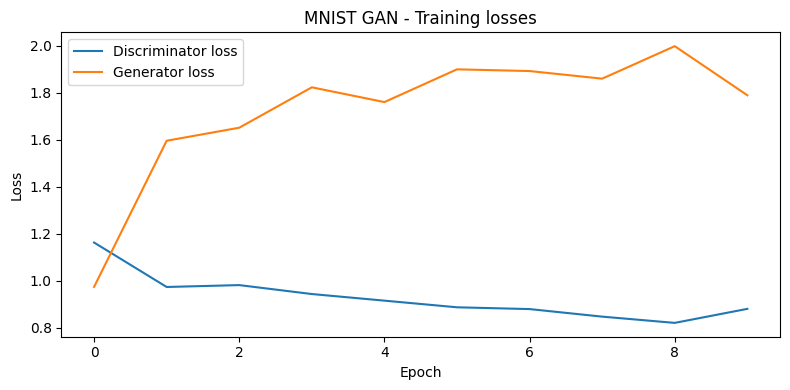

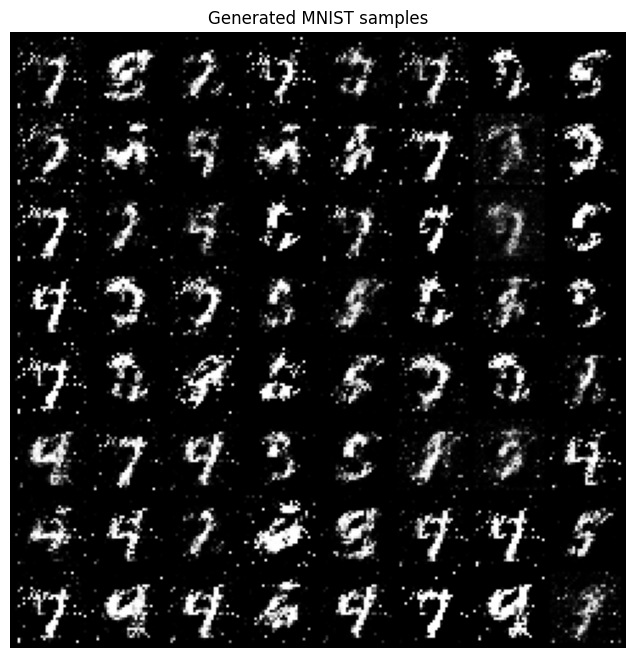

In [7]:

# Wykres strat - MNIST

plt.figure(figsize=(8, 4))
plt.plot(losses_D_mnist, label="Discriminator loss")
plt.plot(losses_G_mnist, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST GAN - Training losses")
plt.legend()
plt.tight_layout()
plt.show()

# Podgląd końcowych próbek - MNIST

G_mnist.eval()
with torch.no_grad():
    samples = G_mnist(fixed_noise_mnist).cpu()

grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap="gray")
plt.title("Generated MNIST samples")
plt.axis("off")
plt.show()

1.2

In [8]:

# DCGAN dla CIFAR-10


CIFAR_OUT = os.path.join(OUT_ROOT, "cifar10")
os.makedirs(CIFAR_OUT, exist_ok=True)

LATENT_DIM_CIFAR = 128
BATCH_SIZE_CIFAR = 128
EPOCHS_CIFAR = 20
LR_CIFAR = 2e-4
THRESH = 0.5


# Dane CIFAR-10

transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_ds_cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_cifar
)

train_dl_cifar = DataLoader(
    train_ds_cifar,
    batch_size=BATCH_SIZE_CIFAR,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)


# Generator CIFAR-10

class GeneratorCIFAR(nn.Module):
    def __init__(self, z_dim=LATENT_DIM_CIFAR):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# Dyskryminator CIFAR-10

class DiscriminatorCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

G_cifar = GeneratorCIFAR().to(device)
D_cifar = DiscriminatorCIFAR().to(device)

criterion = nn.BCELoss()
opt_G_cifar = optim.Adam(G_cifar.parameters(), lr=LR_CIFAR, betas=(0.5, 0.999))
opt_D_cifar = optim.Adam(D_cifar.parameters(), lr=LR_CIFAR, betas=(0.5, 0.999))

fixed_noise_cifar = torch.randn(64, LATENT_DIM_CIFAR, 1, 1, device=device)

losses_G_cifar = []
losses_D_cifar = []


# Trening DCGAN na CIFAR-10

for epoch in range(1, EPOCHS_CIFAR + 1):
    G_cifar.train()
    D_cifar.train()

    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for real_imgs, _ in train_dl_cifar:
        real_imgs = real_imgs.to(device)
        bs = real_imgs.size(0)

        y_real = torch.ones(bs, 1, device=device)
        y_fake = torch.zeros(bs, 1, device=device)

        # --- uczenie D ---
        z = torch.randn(bs, LATENT_DIM_CIFAR, 1, 1, device=device)
        fake_imgs = G_cifar(z).detach()

        loss_D = criterion(D_cifar(real_imgs), y_real) + criterion(D_cifar(fake_imgs), y_fake)

        opt_D_cifar.zero_grad(set_to_none=True)
        loss_D.backward()
        opt_D_cifar.step()

        # --- uczenie G ---
        z = torch.randn(bs, LATENT_DIM_CIFAR, 1, 1, device=device)
        fake_imgs = G_cifar(z)
        loss_G = criterion(D_cifar(fake_imgs), y_real)

        opt_G_cifar.zero_grad(set_to_none=True)
        loss_G.backward()
        opt_G_cifar.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()

    epoch_loss_D /= len(train_dl_cifar)
    epoch_loss_G /= len(train_dl_cifar)

    losses_D_cifar.append(epoch_loss_D)
    losses_G_cifar.append(epoch_loss_G)

    G_cifar.eval()
    with torch.no_grad():
        samples = G_cifar(fixed_noise_cifar).cpu()

    grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))
    utils.save_image(grid, os.path.join(CIFAR_OUT, f"samples_epoch_{epoch:03d}.png"))

    print(f"[CIFAR-10] Epoch {epoch}/{EPOCHS_CIFAR} | loss_D={epoch_loss_D:.4f} | loss_G={epoch_loss_G:.4f}")

[CIFAR-10] Epoch 1/20 | loss_D=0.5377 | loss_G=5.3557
[CIFAR-10] Epoch 2/20 | loss_D=0.6406 | loss_G=3.1778
[CIFAR-10] Epoch 3/20 | loss_D=0.5890 | loss_G=3.2031
[CIFAR-10] Epoch 4/20 | loss_D=0.5385 | loss_G=3.4083
[CIFAR-10] Epoch 5/20 | loss_D=0.5624 | loss_G=3.4184
[CIFAR-10] Epoch 6/20 | loss_D=0.5956 | loss_G=3.2584
[CIFAR-10] Epoch 7/20 | loss_D=0.5945 | loss_G=3.1531
[CIFAR-10] Epoch 8/20 | loss_D=0.5195 | loss_G=3.2924
[CIFAR-10] Epoch 9/20 | loss_D=0.5798 | loss_G=3.0470
[CIFAR-10] Epoch 10/20 | loss_D=0.4473 | loss_G=3.2199
[CIFAR-10] Epoch 11/20 | loss_D=0.5193 | loss_G=3.1712
[CIFAR-10] Epoch 12/20 | loss_D=0.4962 | loss_G=3.1459
[CIFAR-10] Epoch 13/20 | loss_D=0.4943 | loss_G=3.0879
[CIFAR-10] Epoch 14/20 | loss_D=0.4818 | loss_G=3.2385
[CIFAR-10] Epoch 15/20 | loss_D=0.3972 | loss_G=3.3106
[CIFAR-10] Epoch 16/20 | loss_D=0.4169 | loss_G=3.3504
[CIFAR-10] Epoch 17/20 | loss_D=0.4771 | loss_G=3.3923
[CIFAR-10] Epoch 18/20 | loss_D=0.4117 | loss_G=3.3253
[CIFAR-10] Epoch 19

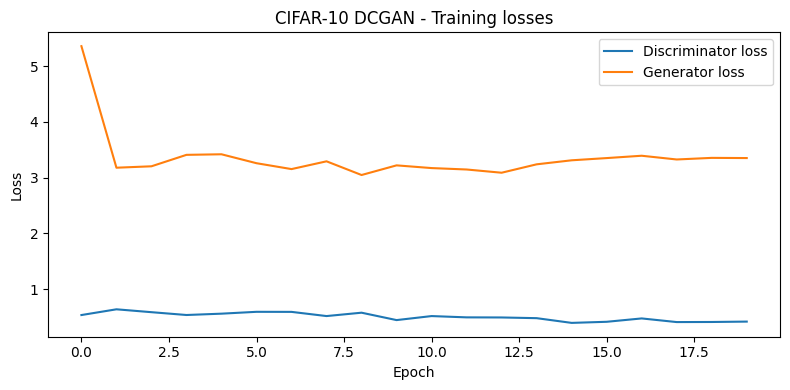

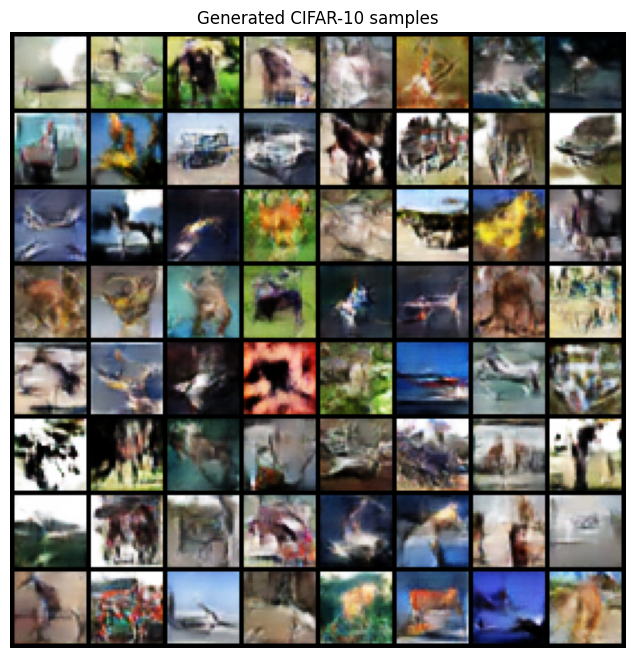

In [9]:

# Wykres strat - CIFAR-10

plt.figure(figsize=(8, 4))
plt.plot(losses_D_cifar, label="Discriminator loss")
plt.plot(losses_G_cifar, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CIFAR-10 DCGAN - Training losses")
plt.legend()
plt.tight_layout()
plt.show()


# Podgląd końcowych próbek - CIFAR-10

G_cifar.eval()
with torch.no_grad():
    samples = G_cifar(fixed_noise_cifar).cpu()

grid = utils.make_grid(samples, nrow=8, normalize=True, value_range=(-1, 1))

plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Generated CIFAR-10 samples")
plt.axis("off")
plt.show()

1.3 i 1.4)

In [10]:

# Ewaluacja: jak D odróżnia real od fake

G_cifar.eval()
D_cifar.eval()

N_REAL = 2000
N_FAKE = 2000

real_imgs = []
it = iter(train_dl_cifar)

while len(real_imgs) * BATCH_SIZE_CIFAR < N_REAL:
    batch, _ = next(it)
    real_imgs.append(batch)

real_imgs = torch.cat(real_imgs, dim=0)[:N_REAL].to(device)

z = torch.randn(N_FAKE, LATENT_DIM_CIFAR, 1, 1, device=device)
with torch.no_grad():
    fake_imgs = G_cifar(z)

x_eval = torch.cat([real_imgs, fake_imgs], dim=0)
y_true = torch.cat([
    torch.ones(N_REAL),
    torch.zeros(N_FAKE)
], dim=0).numpy()

with torch.no_grad():
    scores = D_cifar(x_eval).squeeze(1).cpu().numpy()

y_pred = (scores >= THRESH).astype(int)

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

print("\nConfusion matrix (rows=true [real,fake], cols=pred [real,fake]):\n")
print(cm)

print("\nClassification report (1=real, 0=fake):\n")
print(classification_report(y_true, y_pred, digits=4))


Confusion matrix (rows=true [real,fake], cols=pred [real,fake]):

[[ 877 1123]
 [  21 1979]]

Classification report (1=real, 0=fake):

              precision    recall  f1-score   support

         0.0     0.6380    0.9895    0.7758      2000
         1.0     0.9766    0.4385    0.6052      2000

    accuracy                         0.7140      4000
   macro avg     0.8073    0.7140    0.6905      4000
weighted avg     0.8073    0.7140    0.6905      4000



1.5)

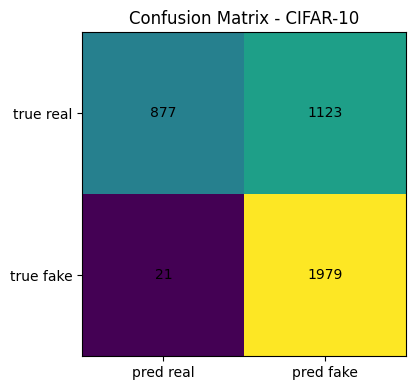

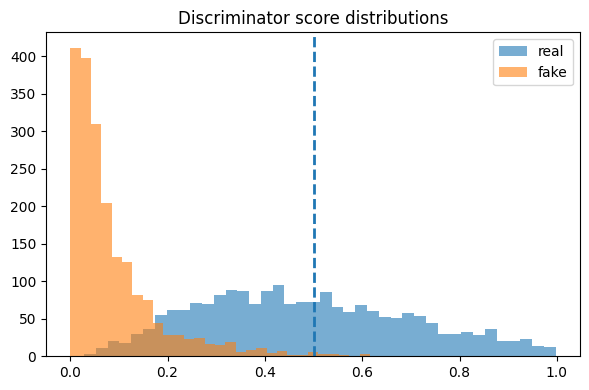

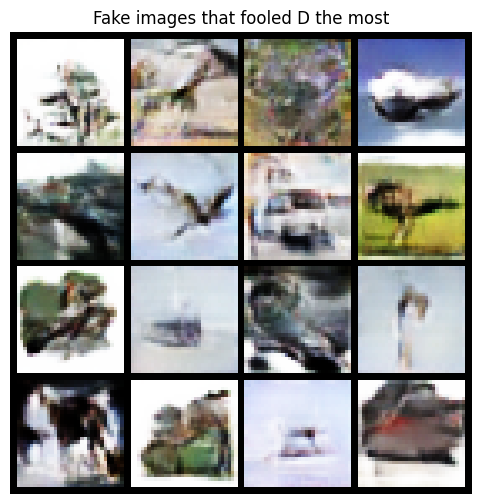

In [11]:

# Confusion matrix

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - CIFAR-10")
plt.xticks([0, 1], ["pred real", "pred fake"])
plt.yticks([0, 1], ["true real", "true fake"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Rozkład score'ów dyskryminatora

plt.figure(figsize=(6, 4))
plt.hist(scores[:N_REAL], bins=40, alpha=0.6, label="real")
plt.hist(scores[N_REAL:], bins=40, alpha=0.6, label="fake")
plt.axvline(THRESH, linestyle="--", linewidth=2)
plt.legend()
plt.title("Discriminator score distributions")
plt.tight_layout()
plt.show()


# Fake obrazy, które najbardziej oszukały D

k = 16
top_idx = np.argsort(scores[N_REAL:])[-k:]

grid = utils.make_grid(
    fake_imgs[top_idx].cpu(),
    nrow=4,
    normalize=True,
    value_range=(-1, 1)
)

plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Fake images that fooled D the most")
plt.axis("off")
plt.show()

1.6)

In [12]:

# Prosta interpretacja wyników

print("=== ANALIZA STABILNOŚCI TRENINGU ===\n")

print("MNIST:")
print(f"- Początkowa strata D: {losses_D_mnist[0]:.4f}")
print(f"- Końcowa strata D:    {losses_D_mnist[-1]:.4f}")
print(f"- Początkowa strata G: {losses_G_mnist[0]:.4f}")
print(f"- Końcowa strata G:    {losses_G_mnist[-1]:.4f}")

print("\nCIFAR-10:")
print(f"- Początkowa strata D: {losses_D_cifar[0]:.4f}")
print(f"- Końcowa strata D:    {losses_D_cifar[-1]:.4f}")
print(f"- Początkowa strata G: {losses_G_cifar[0]:.4f}")
print(f"- Końcowa strata G:    {losses_G_cifar[-1]:.4f}")

print("\nWnioski ogólne:")
print("- Jeśli generator poprawia jakość obrazów, a dyskryminator nie dominuje całkowicie, trening jest względnie stabilny.")
print("- Dla MNIST próbki zwykle poprawiają się szybciej, bo dane są prostsze.")
print("- Dla CIFAR-10 trening jest trudniejszy, bo obrazy są kolorowe i bardziej złożone.")
print("- Jeżeli wszystkie fake obrazy są bardzo podobne, może pojawić się mode collapse.")

=== ANALIZA STABILNOŚCI TRENINGU ===

MNIST:
- Początkowa strata D: 1.1632
- Końcowa strata D:    0.8812
- Początkowa strata G: 0.9745
- Końcowa strata G:    1.7896

CIFAR-10:
- Początkowa strata D: 0.5377
- Końcowa strata D:    0.4204
- Początkowa strata G: 5.3557
- Końcowa strata G:    3.3508

Wnioski ogólne:
- Jeśli generator poprawia jakość obrazów, a dyskryminator nie dominuje całkowicie, trening jest względnie stabilny.
- Dla MNIST próbki zwykle poprawiają się szybciej, bo dane są prostsze.
- Dla CIFAR-10 trening jest trudniejszy, bo obrazy są kolorowe i bardziej złożone.
- Jeżeli wszystkie fake obrazy są bardzo podobne, może pojawić się mode collapse.


**Cel zadania 2**

1. Załaduj zbiór CIFAR-10:
   * przeskaluj wartości pikseli do zakresu ([0,1]),
   * podziel dane na zbiór treningowy, testowy i walidacyjny.

2. Wygeneruj syntetyczny zbiór danych przy użyciu funkcji `make_blobs` z scikit-learn:

   * liczba próbek: min. 5000,
   * liczba cech: 77 (im więcej tym lepiej),
   * liczba klastrów: 32.

3. Zwizualizuj dane syntetyczne:

   * zredukuj wymiarowość do 2D (np. PCA),
   * wykonaj wykres punktowy z kolorowaniem względem etykiet.

## Autoenkoder dla CIFAR-10
   * zawiera co najmniej 2 warstwy konwolucyjne w encoderze,
   * redukuje reprezentację do przestrzeni latentnej o wymiarze 64,
   * rekonstruuje obraz o oryginalnym rozmiarze.---

## Autoenkoder dla danych syntetycznych (autoenkoder MLP)
   * encoder redukujący dane z 10 wymiarów do 2,
   * decoder rekonstruujący dane do oryginalnego wymiaru.

# Ewaluacja

Dla CIFAR-10:
  * pokaż przykłady: oryginalny obraz vs rekonstrukcja,
  * oceń jakość rekonstrukcji wizualnie i numerycznie (MSE).

Dla danych syntetycznych:
  * porównaj wartości wejściowe i wyjściowe,
  * oblicz średni błąd rekonstrukcji.

## Przestrzeń latentna

Dla danych syntetycznych:
  * zwizualizuj przestrzeń latentną (2D scatter plot),
  * pokoloruj punkty według rzeczywistych klastrów,
  * oceń, czy struktura została zachowana.

Dla CIFAR-10:
  * zredukuj latent space do 2D (PCA lub t-SNE),
  * oceń separację klas.


Zmień wymiar przestrzeni latentnej:
  * dla danych syntetycznych: 2 → 5,
  * dla CIFAR: 64 → 128,
  * porównaj wpływ na rekonstrukcję i strukturę latentną.

Dodaj regularyzację (np. dropout lub L2):
  * sprawdź wpływ na overfitting,
  * porównaj błędy walidacyjne.

---




Zadanie 2 )

Importy i konfiguracja

In [13]:


import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)

Device: cuda


CIFAR-10: ładowanie i podział na train / val / test

In [15]:

# CIFAR-10
# skala [0, 1]
# podział na train / val / test


transform_cifar = transforms.ToTensor()  # daje zakres [0,1]

full_train_cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_cifar
)

test_cifar = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_cifar
)

train_size = int(0.8 * len(full_train_cifar))   # 40000
val_size = len(full_train_cifar) - train_size   # 10000

train_cifar, val_cifar = random_split(
    full_train_cifar,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader_cifar = DataLoader(train_cifar, batch_size=batch_size, shuffle=True)
val_loader_cifar = DataLoader(val_cifar, batch_size=batch_size, shuffle=False)
test_loader_cifar = DataLoader(test_cifar, batch_size=batch_size, shuffle=False)

print("CIFAR-10:")
print("train:", len(train_cifar))
print("val:  ", len(val_cifar))
print("test: ", len(test_cifar))

CIFAR-10:
train: 40000
val:   10000
test:  10000


Dane syntetyczne: make_blobs + PCA do 2D

In [16]:

# Dane syntetyczne
# min. 5000 próbek
# 77 cech
# 32 klastry


N_SAMPLES = 5000
N_FEATURES = 77
N_CLUSTERS = 32

X_syn, y_syn = make_blobs(
    n_samples=N_SAMPLES,
    n_features=N_FEATURES,
    centers=N_CLUSTERS,
    cluster_std=2.0,
    random_state=42
)

print("Synthetic shape:", X_syn.shape)
print("Labels shape:", y_syn.shape)
print("Number of clusters:", len(np.unique(y_syn)))

Synthetic shape: (5000, 77)
Labels shape: (5000,)
Number of clusters: 32


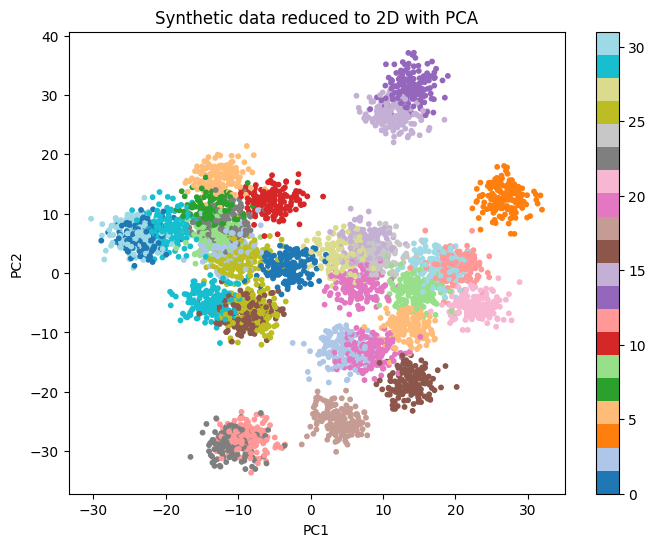

In [17]:
# PCA do 2D i wykres punktowy

pca_syn = PCA(n_components=2)
X_syn_2d = pca_syn.fit_transform(X_syn)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_syn_2d[:, 0], X_syn_2d[:, 1], c=y_syn, s=10, cmap="tab20")
plt.colorbar(scatter)
plt.title("Synthetic data reduced to 2D with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Podział danych syntetycznych na train / val / test

In [18]:

# Podział danych syntetycznych


X_syn = X_syn.astype(np.float32)

# prosty ręczny split
idx = np.random.permutation(len(X_syn))

train_end = int(0.8 * len(X_syn))
val_end = int(0.9 * len(X_syn))

train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

X_train_syn = X_syn[train_idx]
y_train_syn = y_syn[train_idx]

X_val_syn = X_syn[val_idx]
y_val_syn = y_syn[val_idx]

X_test_syn = X_syn[test_idx]
y_test_syn = y_syn[test_idx]

train_ds_syn = TensorDataset(torch.tensor(X_train_syn), torch.tensor(y_train_syn))
val_ds_syn = TensorDataset(torch.tensor(X_val_syn), torch.tensor(y_val_syn))
test_ds_syn = TensorDataset(torch.tensor(X_test_syn), torch.tensor(y_test_syn))

train_loader_syn = DataLoader(train_ds_syn, batch_size=128, shuffle=True)
val_loader_syn = DataLoader(val_ds_syn, batch_size=128, shuffle=False)
test_loader_syn = DataLoader(test_ds_syn, batch_size=128, shuffle=False)

print("Synthetic:")
print("train:", len(train_ds_syn))
print("val:  ", len(val_ds_syn))
print("test: ", len(test_ds_syn))

Synthetic:
train: 4000
val:   500
test:  500


Autoenkoder dla CIFAR-10
Model: latent_dim=64

In [19]:

# Convolutional Autoencoder for CIFAR-10
# latent dim = 64
# encoder ma min. 2 warstwy conv


class CIFARAutoencoder(nn.Module):
    def __init__(self, latent_dim=64, dropout_p=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 32x16x16
            nn.ReLU(),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 128x4x4
            nn.ReLU(),
            nn.Flatten(),

            nn.Linear(128 * 4 * 4, latent_dim)
        )

        self.decoder_fc = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 64x8x8
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 32x16x16
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 3x32x32
            nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 128, 4, 4)
        return self.decoder(x)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

Funkcje treningu i ewaluacji

In [20]:
def train_autoencoder_image(model, train_loader, val_loader, epochs=10, lr=1e-3, weight_decay=0.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, _ in train_loader:
            x = x.to(device)

            x_hat = model(x)
            loss = criterion(x_hat, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat = model(x)
                loss = criterion(x_hat, x)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

    return train_losses, val_losses

Trening CIFAR AE 64

In [21]:
cifar_ae_64 = CIFARAutoencoder(latent_dim=64, dropout_p=0.0).to(device)
train_losses_c64, val_losses_c64 = train_autoencoder_image(
    cifar_ae_64,
    train_loader_cifar,
    val_loader_cifar,
    epochs=10,
    lr=1e-3,
    weight_decay=0.0
)

Epoch 1/10 | train=0.026572 | val=0.014851
Epoch 2/10 | train=0.012376 | val=0.010882
Epoch 3/10 | train=0.009940 | val=0.009216
Epoch 4/10 | train=0.008760 | val=0.008487
Epoch 5/10 | train=0.008235 | val=0.008145
Epoch 6/10 | train=0.008038 | val=0.008112
Epoch 7/10 | train=0.007920 | val=0.008016
Epoch 8/10 | train=0.007850 | val=0.008298
Epoch 9/10 | train=0.007803 | val=0.007947
Epoch 10/10 | train=0.007748 | val=0.007886


Wykres strat CIFAR AE 64

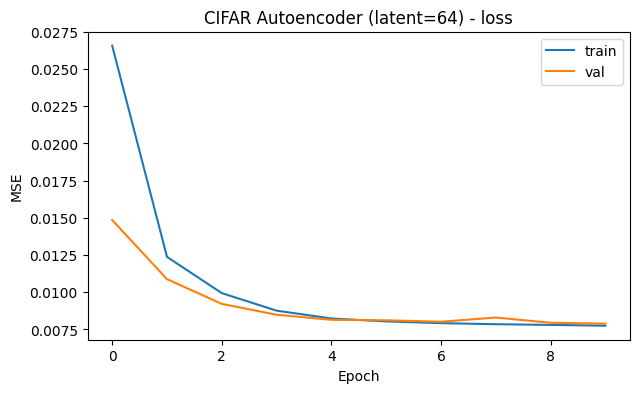

In [22]:
plt.figure(figsize=(7,4))
plt.plot(train_losses_c64, label="train")
plt.plot(val_losses_c64, label="val")
plt.title("CIFAR Autoencoder (latent=64) - loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

Rekonstrukcje CIFAR i MSE

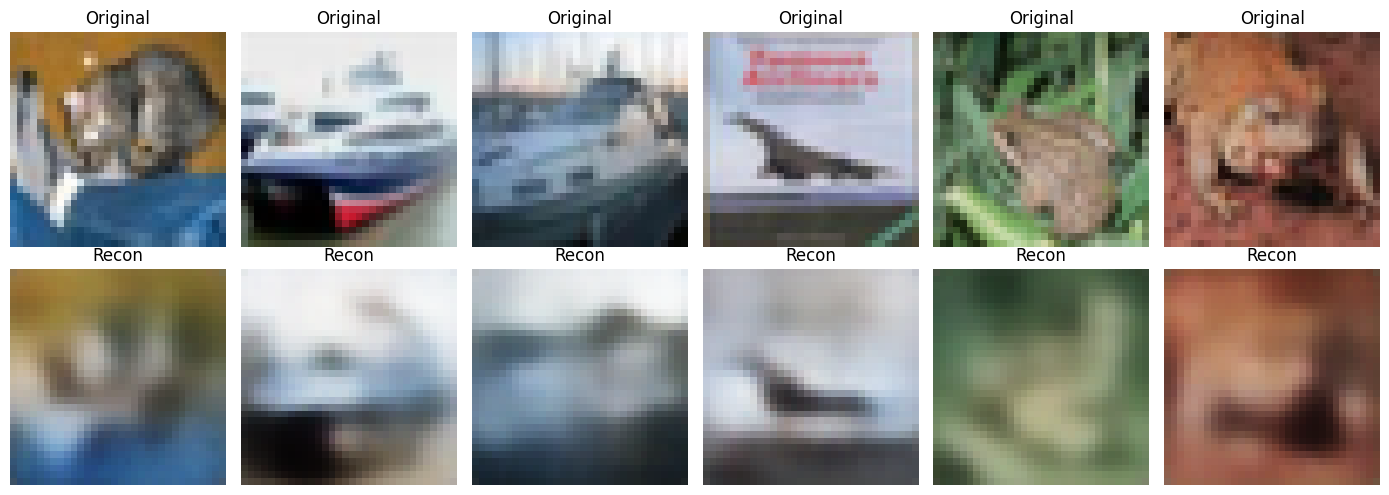

In [23]:

# Oryginał vs rekonstrukcja


cifar_ae_64.eval()
with torch.no_grad():
    images, labels = next(iter(test_loader_cifar))
    images = images.to(device)
    recon = cifar_ae_64(images)

images = images.cpu()
recon = recon.cpu()

n = 6
plt.figure(figsize=(14, 5))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(np.transpose(recon[i].numpy(), (1, 2, 0)))
    plt.title("Recon")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# MSE na zbiorze testowym

criterion = nn.MSELoss()
cifar_ae_64.eval()

mse_test_c64 = 0.0
with torch.no_grad():
    for x, _ in test_loader_cifar:
        x = x.to(device)
        x_hat = cifar_ae_64(x)
        mse_test_c64 += criterion(x_hat, x).item()

mse_test_c64 /= len(test_loader_cifar)
print("CIFAR test MSE (latent=64):", mse_test_c64)

CIFAR test MSE (latent=64): 0.007849355676223206


Latent space CIFAR -> PCA 2D

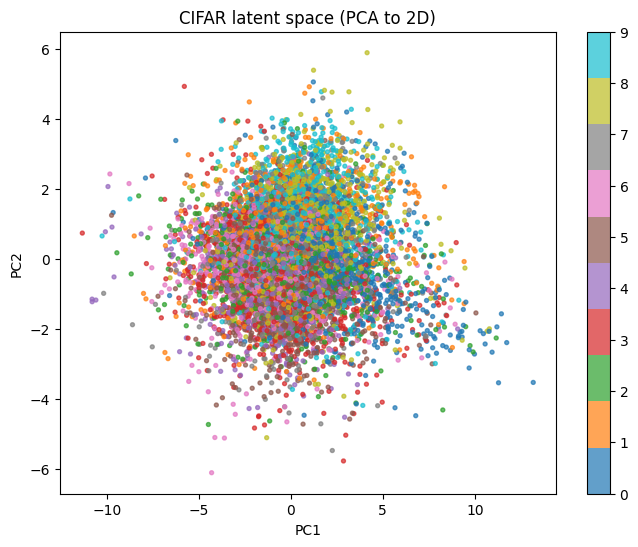

In [25]:
latents_cifar = []
labels_cifar = []

cifar_ae_64.eval()
with torch.no_grad():
    for x, y in test_loader_cifar:
        x = x.to(device)
        z = cifar_ae_64.encode(x)
        latents_cifar.append(z.cpu())
        labels_cifar.append(y)

latents_cifar = torch.cat(latents_cifar).numpy()
labels_cifar = torch.cat(labels_cifar).numpy()

pca_cifar = PCA(n_components=2)
latents_cifar_2d = pca_cifar.fit_transform(latents_cifar)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latents_cifar_2d[:, 0],
    latents_cifar_2d[:, 1],
    c=labels_cifar,
    s=8,
    alpha=0.7,
    cmap="tab10"
)
plt.colorbar(scatter)
plt.title("CIFAR latent space (PCA to 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Autoenkoder MLP dla danych syntetycznych
Model latent=2

In [26]:

# MLP Autoencoder for synthetic data
# 77 -> ... -> 2 -> ... -> 77


class SyntheticAutoencoder(nn.Module):
    def __init__(self, input_dim=77, latent_dim=2, dropout_p=0.0):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, input_dim)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        x_hat = self.decode(z)
        return x_hat

Trening syntetycznego AE

In [27]:
def train_autoencoder_tabular(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=0.0):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, _ in train_loader:
            x = x.to(device)

            x_hat = model(x)
            loss = criterion(x_hat, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                x_hat = model(x)
                loss = criterion(x_hat, x)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

    return train_losses, val_losses

In [28]:
syn_ae_2 = SyntheticAutoencoder(input_dim=77, latent_dim=2, dropout_p=0.0).to(device)
train_losses_s2, val_losses_s2 = train_autoencoder_tabular(
    syn_ae_2,
    train_loader_syn,
    val_loader_syn,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0
)

Epoch 1/20 | train=35.939079 | val=32.826584
Epoch 2/20 | train=30.584791 | val=29.102549
Epoch 3/20 | train=28.236102 | val=27.330826
Epoch 4/20 | train=26.569848 | val=25.446725
Epoch 5/20 | train=24.604071 | val=23.438091
Epoch 6/20 | train=22.635213 | val=21.737606
Epoch 7/20 | train=20.927247 | val=20.017758
Epoch 8/20 | train=19.371409 | val=18.546588
Epoch 9/20 | train=18.109950 | val=17.089461
Epoch 10/20 | train=16.668348 | val=15.768759
Epoch 11/20 | train=15.535146 | val=14.732654
Epoch 12/20 | train=14.334320 | val=13.529201
Epoch 13/20 | train=13.323495 | val=12.634228
Epoch 14/20 | train=12.426990 | val=11.689831
Epoch 15/20 | train=11.491463 | val=11.074046
Epoch 16/20 | train=10.781569 | val=10.244547
Epoch 17/20 | train=10.012564 | val=9.530588
Epoch 18/20 | train=9.434573 | val=9.021696
Epoch 19/20 | train=8.959305 | val=8.620331
Epoch 20/20 | train=8.365662 | val=8.195186


Wykres strat syntetyczny AE

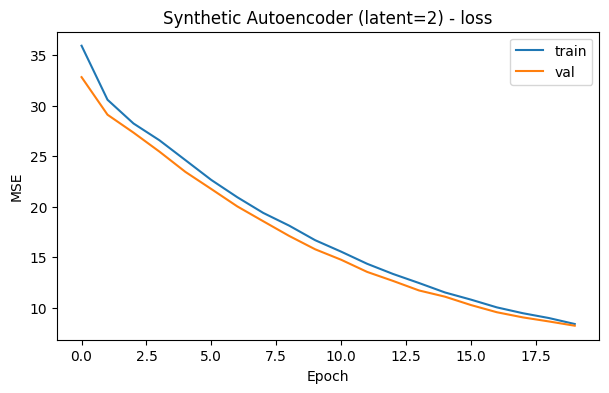

In [29]:
plt.figure(figsize=(7,4))
plt.plot(train_losses_s2, label="train")
plt.plot(val_losses_s2, label="val")
plt.title("Synthetic Autoencoder (latent=2) - loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

Porównanie wejście / wyjście + średni błąd

In [30]:
syn_ae_2.eval()

with torch.no_grad():
    x_batch, y_batch = next(iter(test_loader_syn))
    x_batch = x_batch.to(device)
    x_recon = syn_ae_2(x_batch)

x_batch_np = x_batch.cpu().numpy()
x_recon_np = x_recon.cpu().numpy()

print("Przykładowe porównanie wejście vs wyjście dla 3 próbek:\n")
for i in range(3):
    print(f"--- Próbka {i+1} ---")
    print("Wejście   :", np.round(x_batch_np[i][:10], 3))
    print("Wyjście   :", np.round(x_recon_np[i][:10], 3))
    print()

Przykładowe porównanie wejście vs wyjście dla 3 próbek:

--- Próbka 1 ---
Wejście   : [ -1.984 -10.81    0.705  -3.854   6.768  -0.46    7.259  -5.682   4.006
   5.205]
Wyjście   : [ -5.05  -10.366   2.399  -1.94    7.553  -0.509   8.806  -6.794   6.4
   5.734]

--- Próbka 2 ---
Wejście   : [-2.264 -8.726 -0.856 -1.462  3.646 -6.834 -6.306  4.57  10.427  4.297]
Wyjście   : [-0.206 -7.962 -4.468  0.48   2.84  -3.652 -5.906  5.418  9.231 -1.137]

--- Próbka 3 ---
Wejście   : [ 3.616  3.281  5.469 -4.666 -6.338  2.569 -6.977 11.709 -1.613 -5.854]
Wyjście   : [ 1.879  8.439  4.007 -2.289 -6.707 -0.929 -7.441  9.993 -2.039  0.318]



In [31]:
# średni błąd rekonstrukcji na teście
syn_ae_2.eval()
mse_test_s2 = 0.0

with torch.no_grad():
    for x, _ in test_loader_syn:
        x = x.to(device)
        x_hat = syn_ae_2(x)
        mse_test_s2 += nn.functional.mse_loss(x_hat, x).item()

mse_test_s2 /= len(test_loader_syn)
print("Synthetic test MSE (latent=2):", mse_test_s2)

Synthetic test MSE (latent=2): 8.336341142654419


Przestrzeń latentna dla danych syntetycznych

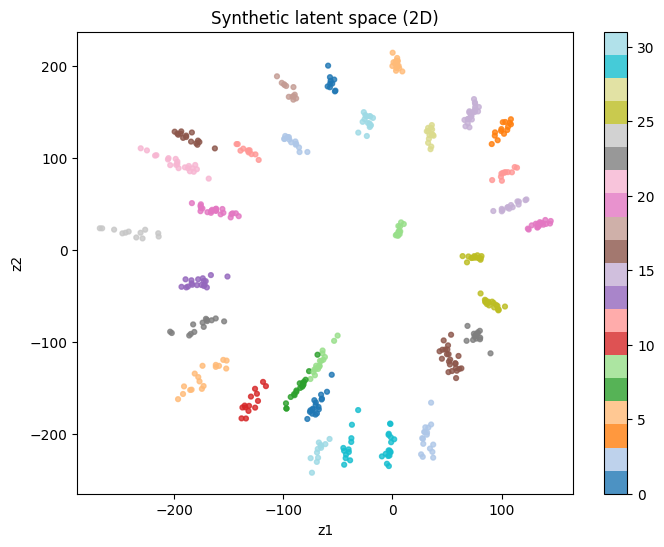

In [32]:
latent_syn = []
labels_syn = []

syn_ae_2.eval()
with torch.no_grad():
    for x, y in test_loader_syn:
        x = x.to(device)
        z = syn_ae_2.encode(x)
        latent_syn.append(z.cpu())
        labels_syn.append(y)

latent_syn = torch.cat(latent_syn).numpy()
labels_syn = torch.cat(labels_syn).numpy()

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latent_syn[:, 0],
    latent_syn[:, 1],
    c=labels_syn,
    s=12,
    alpha=0.8,
    cmap="tab20"
)
plt.colorbar(scatter)
plt.title("Synthetic latent space (2D)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Zmiana latent_dim
Synthetic: 2 -> 5

In [33]:
syn_ae_5 = SyntheticAutoencoder(input_dim=77, latent_dim=5, dropout_p=0.0).to(device)
train_losses_s5, val_losses_s5 = train_autoencoder_tabular(
    syn_ae_5,
    train_loader_syn,
    val_loader_syn,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0
)

Epoch 1/20 | train=35.852694 | val=32.148243
Epoch 2/20 | train=27.854179 | val=23.683932
Epoch 3/20 | train=19.643105 | val=15.592526
Epoch 4/20 | train=12.327731 | val=9.755534
Epoch 5/20 | train=7.699078 | val=6.538815
Epoch 6/20 | train=5.644126 | val=5.253328
Epoch 7/20 | train=4.735458 | val=4.588859
Epoch 8/20 | train=4.327398 | val=4.338330
Epoch 9/20 | train=4.148492 | val=4.242770
Epoch 10/20 | train=4.086371 | val=4.207326
Epoch 11/20 | train=4.071226 | val=4.158450
Epoch 12/20 | train=4.046200 | val=4.157464
Epoch 13/20 | train=4.027766 | val=4.142663
Epoch 14/20 | train=4.022954 | val=4.119348
Epoch 15/20 | train=4.004955 | val=4.121394
Epoch 16/20 | train=4.001842 | val=4.129074
Epoch 17/20 | train=3.992815 | val=4.110064
Epoch 18/20 | train=3.989453 | val=4.105065
Epoch 19/20 | train=3.970004 | val=4.118620
Epoch 20/20 | train=3.960773 | val=4.090518


In [34]:
syn_ae_5.eval()
mse_test_s5 = 0.0

with torch.no_grad():
    for x, _ in test_loader_syn:
        x = x.to(device)
        x_hat = syn_ae_5(x)
        mse_test_s5 += nn.functional.mse_loss(x_hat, x).item()

mse_test_s5 /= len(test_loader_syn)

print("Synthetic test MSE (latent=2):", mse_test_s2)
print("Synthetic test MSE (latent=5):", mse_test_s5)

Synthetic test MSE (latent=2): 8.336341142654419
Synthetic test MSE (latent=5): 4.021129071712494


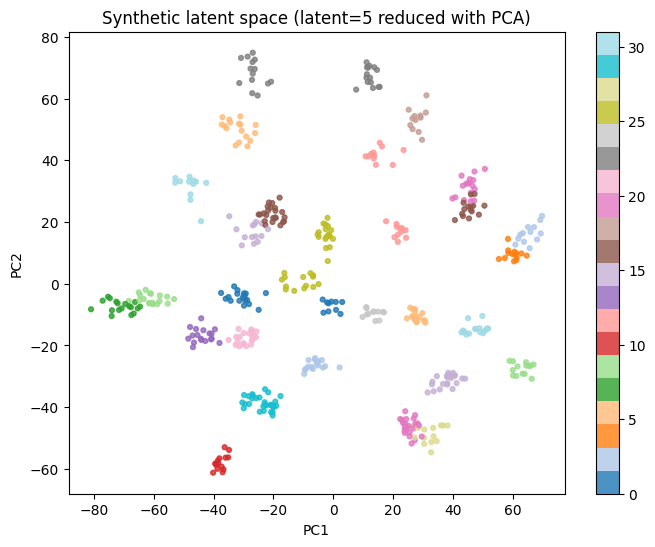

In [35]:
# latent 5 -> redukcja PCA do 2D
latent_syn_5 = []
labels_syn_5 = []

syn_ae_5.eval()
with torch.no_grad():
    for x, y in test_loader_syn:
        x = x.to(device)
        z = syn_ae_5.encode(x)
        latent_syn_5.append(z.cpu())
        labels_syn_5.append(y)

latent_syn_5 = torch.cat(latent_syn_5).numpy()
labels_syn_5 = torch.cat(labels_syn_5).numpy()

latent_syn_5_2d = PCA(n_components=2).fit_transform(latent_syn_5)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latent_syn_5_2d[:, 0],
    latent_syn_5_2d[:, 1],
    c=labels_syn_5,
    s=12,
    alpha=0.8,
    cmap="tab20"
)
plt.colorbar(scatter)
plt.title("Synthetic latent space (latent=5 reduced with PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

CIFAR: 64 -> 128

In [36]:
cifar_ae_128 = CIFARAutoencoder(latent_dim=128, dropout_p=0.0).to(device)
train_losses_c128, val_losses_c128 = train_autoencoder_image(
    cifar_ae_128,
    train_loader_cifar,
    val_loader_cifar,
    epochs=10,
    lr=1e-3,
    weight_decay=0.0
)

Epoch 1/10 | train=0.024574 | val=0.013475
Epoch 2/10 | train=0.011402 | val=0.009950
Epoch 3/10 | train=0.009066 | val=0.008287
Epoch 4/10 | train=0.007663 | val=0.007150
Epoch 5/10 | train=0.006719 | val=0.006484
Epoch 6/10 | train=0.006124 | val=0.005908
Epoch 7/10 | train=0.005694 | val=0.005615
Epoch 8/10 | train=0.005384 | val=0.005344
Epoch 9/10 | train=0.005168 | val=0.005313
Epoch 10/10 | train=0.005023 | val=0.005060


In [37]:
cifar_ae_128.eval()
mse_test_c128 = 0.0

with torch.no_grad():
    for x, _ in test_loader_cifar:
        x = x.to(device)
        x_hat = cifar_ae_128(x)
        mse_test_c128 += nn.MSELoss()(x_hat, x).item()

mse_test_c128 /= len(test_loader_cifar)

print("CIFAR test MSE (latent=64): ", mse_test_c64)
print("CIFAR test MSE (latent=128):", mse_test_c128)

CIFAR test MSE (latent=64):  0.007849355676223206
CIFAR test MSE (latent=128): 0.005026512083750737


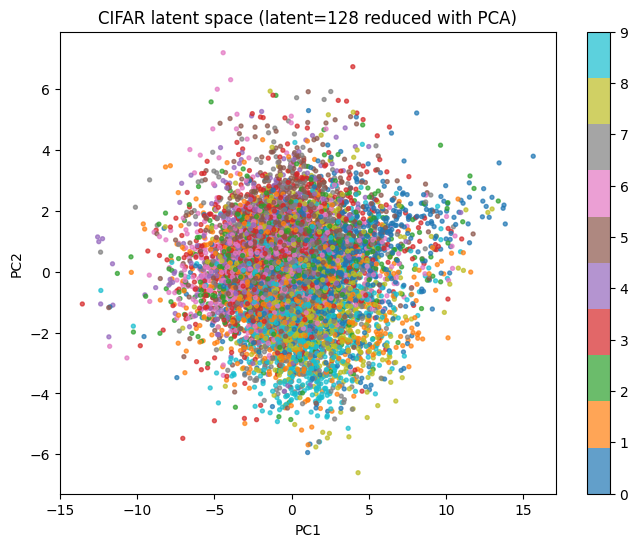

In [38]:
latents_cifar_128 = []
labels_cifar_128 = []

cifar_ae_128.eval()
with torch.no_grad():
    for x, y in test_loader_cifar:
        x = x.to(device)
        z = cifar_ae_128.encode(x)
        latents_cifar_128.append(z.cpu())
        labels_cifar_128.append(y)

latents_cifar_128 = torch.cat(latents_cifar_128).numpy()
labels_cifar_128 = torch.cat(labels_cifar_128).numpy()

latents_cifar_128_2d = PCA(n_components=2).fit_transform(latents_cifar_128)

plt.figure(figsize=(8,6))
scatter = plt.scatter(
    latents_cifar_128_2d[:, 0],
    latents_cifar_128_2d[:, 1],
    c=labels_cifar_128,
    s=8,
    alpha=0.7,
    cmap="tab10"
)
plt.colorbar(scatter)
plt.title("CIFAR latent space (latent=128 reduced with PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Regularyzacja: dropout albo L2
Synthetic z regularyzacją

In [39]:
syn_ae_2_reg = SyntheticAutoencoder(input_dim=77, latent_dim=2, dropout_p=0.2).to(device)
train_losses_s2_reg, val_losses_s2_reg = train_autoencoder_tabular(
    syn_ae_2_reg,
    train_loader_syn,
    val_loader_syn,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4
)

Epoch 1/20 | train=35.830073 | val=32.777017
Epoch 2/20 | train=31.488128 | val=30.284894
Epoch 3/20 | train=29.151921 | val=28.295566
Epoch 4/20 | train=27.151040 | val=26.378221
Epoch 5/20 | train=25.323426 | val=24.671272
Epoch 6/20 | train=23.805571 | val=23.134553
Epoch 7/20 | train=22.593762 | val=22.038260
Epoch 8/20 | train=21.390897 | val=20.878330
Epoch 9/20 | train=20.472951 | val=19.875848
Epoch 10/20 | train=19.682394 | val=18.900201
Epoch 11/20 | train=19.006789 | val=18.328283
Epoch 12/20 | train=18.303581 | val=17.666501
Epoch 13/20 | train=17.563756 | val=16.887778
Epoch 14/20 | train=17.086401 | val=16.185564
Epoch 15/20 | train=16.394609 | val=15.401054
Epoch 16/20 | train=15.883026 | val=14.835057
Epoch 17/20 | train=15.383919 | val=14.291704
Epoch 18/20 | train=14.872486 | val=13.740577
Epoch 19/20 | train=14.401281 | val=13.277940
Epoch 20/20 | train=13.897315 | val=12.723260


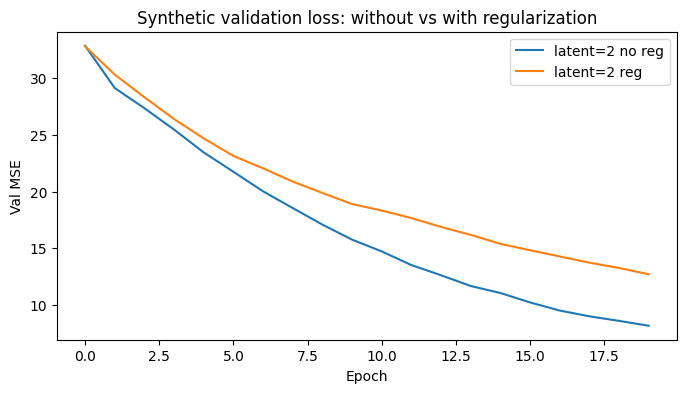

In [40]:
plt.figure(figsize=(8,4))
plt.plot(val_losses_s2, label="latent=2 no reg")
plt.plot(val_losses_s2_reg, label="latent=2 reg")
plt.title("Synthetic validation loss: without vs with regularization")
plt.xlabel("Epoch")
plt.ylabel("Val MSE")
plt.legend()
plt.show()

CIFAR z regularyzacją

In [41]:
cifar_ae_64_reg = CIFARAutoencoder(latent_dim=64, dropout_p=0.2).to(device)
train_losses_c64_reg, val_losses_c64_reg = train_autoencoder_image(
    cifar_ae_64_reg,
    train_loader_cifar,
    val_loader_cifar,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4
)

Epoch 1/10 | train=0.031188 | val=0.021182
Epoch 2/10 | train=0.019681 | val=0.017708
Epoch 3/10 | train=0.017744 | val=0.017848
Epoch 4/10 | train=0.016281 | val=0.016594
Epoch 5/10 | train=0.014541 | val=0.014768
Epoch 6/10 | train=0.013678 | val=0.013568
Epoch 7/10 | train=0.013204 | val=0.013568
Epoch 8/10 | train=0.012866 | val=0.014471
Epoch 9/10 | train=0.012627 | val=0.014474
Epoch 10/10 | train=0.012369 | val=0.013968


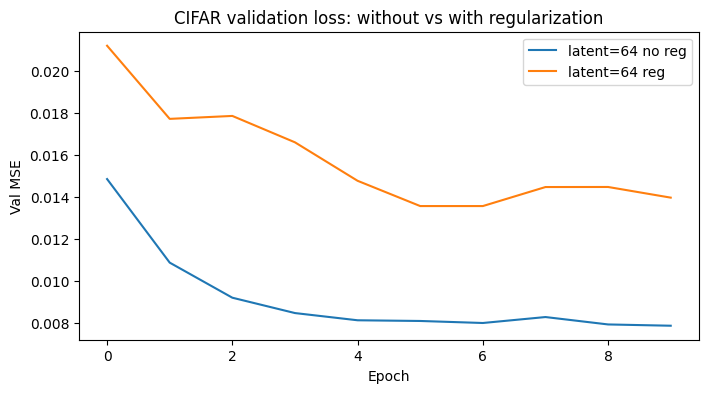

In [42]:
plt.figure(figsize=(8,4))
plt.plot(val_losses_c64, label="latent=64 no reg")
plt.plot(val_losses_c64_reg, label="latent=64 reg")
plt.title("CIFAR validation loss: without vs with regularization")
plt.xlabel("Epoch")
plt.ylabel("Val MSE")
plt.legend()
plt.show()

Krótkie porównanie końcowe

In [44]:
print(" PODSUMOWANIE ")
print(f"SYNTHETIC MSE latent=2 : {mse_test_s2:.6f}")
print(f"SYNTHETIC MSE latent=5 : {mse_test_s5:.6f}")
print(f"CIFAR MSE latent=64    : {mse_test_c64:.6f}")
print(f"CIFAR MSE latent=128   : {mse_test_c128:.6f}")

 PODSUMOWANIE 
SYNTHETIC MSE latent=2 : 8.336341
SYNTHETIC MSE latent=5 : 4.021129
CIFAR MSE latent=64    : 0.007849
CIFAR MSE latent=128   : 0.005027
